In [1]:
%load_ext autoreload
# %reload_ext autoreload
%autoreload 1

%aimport b6_epilepsies 
import b6_epilepsies as b6 #.py file in the same dir as this .ipynb
from b6_epilepsies_func import *
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define input variables
date   = "250314"
box1   = "16"
box2   = "17"
exp    = "ALDH7A1_paradigm"
export = False

# omit = {box1:['H7','D8','D9','D12']}
    
para_obj_raw = b6.RawData(date, box1, box2, exp, export) #.prepped_data attribute to access df

# ald_lys_obj_mid  = b6.MiddurData(date, box1, box2, exp, export, omit=omit) #.prepped_data attribute to access df
df_raw = para_obj_raw.df

Initialising RawData...
Start of experiment: 2025-03-14 18:29:32
Instantiated using 250314_16_17_ALDH7A1_paradigm/250314_16_17_ALDH7A1_paradigm_processed.csv, no need to prepare raw data.
Done.


In [3]:
segment = df_raw[(df_raw['elapsed_time'] >= 0) & (df_raw['elapsed_time'] <= 60)]

In [4]:
# Run the parameter sweep
sweep_results = sweep_seizure_parameters_detailed(
    detect_seizures_func=para_obj_raw.detect_seizures,  # Your function
    raw_data_df=segment,  
    param_ranges={
        'min_frame_duration_range': range(20, 51, 5),    # 10 to 50 frames
        'min_ibi_range': range(1, 16, 2)                 # 1 to 15 frames
    }
)

# Find optimal parameters
optimal_params = find_optimal_parameters_standalone(sweep_results,para_obj_raw.name)

# Now you can use these optimal parameters manually
print(f"\nUse these parameters in your analysis:")
print(f"min_frame_duration = {optimal_params['min_frame_duration']}")
print(f"min_ibi = {optimal_params['min_ibi']}")

Testing 1/56: min_duration=20, min_ibi=1
Testing 2/56: min_duration=20, min_ibi=3
Testing 3/56: min_duration=20, min_ibi=5
Testing 4/56: min_duration=20, min_ibi=7
Testing 5/56: min_duration=20, min_ibi=9
Testing 6/56: min_duration=20, min_ibi=11
Testing 7/56: min_duration=20, min_ibi=13
Testing 8/56: min_duration=20, min_ibi=15
Testing 9/56: min_duration=25, min_ibi=1
Testing 10/56: min_duration=25, min_ibi=3
Testing 11/56: min_duration=25, min_ibi=5
Testing 12/56: min_duration=25, min_ibi=7
Testing 13/56: min_duration=25, min_ibi=9
Testing 14/56: min_duration=25, min_ibi=11
Testing 15/56: min_duration=25, min_ibi=13
Testing 16/56: min_duration=25, min_ibi=15
Testing 17/56: min_duration=30, min_ibi=1
Testing 18/56: min_duration=30, min_ibi=3
Testing 19/56: min_duration=30, min_ibi=5
Testing 20/56: min_duration=30, min_ibi=7
Testing 21/56: min_duration=30, min_ibi=9
Testing 22/56: min_duration=30, min_ibi=11
Testing 23/56: min_duration=30, min_ibi=13
Testing 24/56: min_duration=30, min

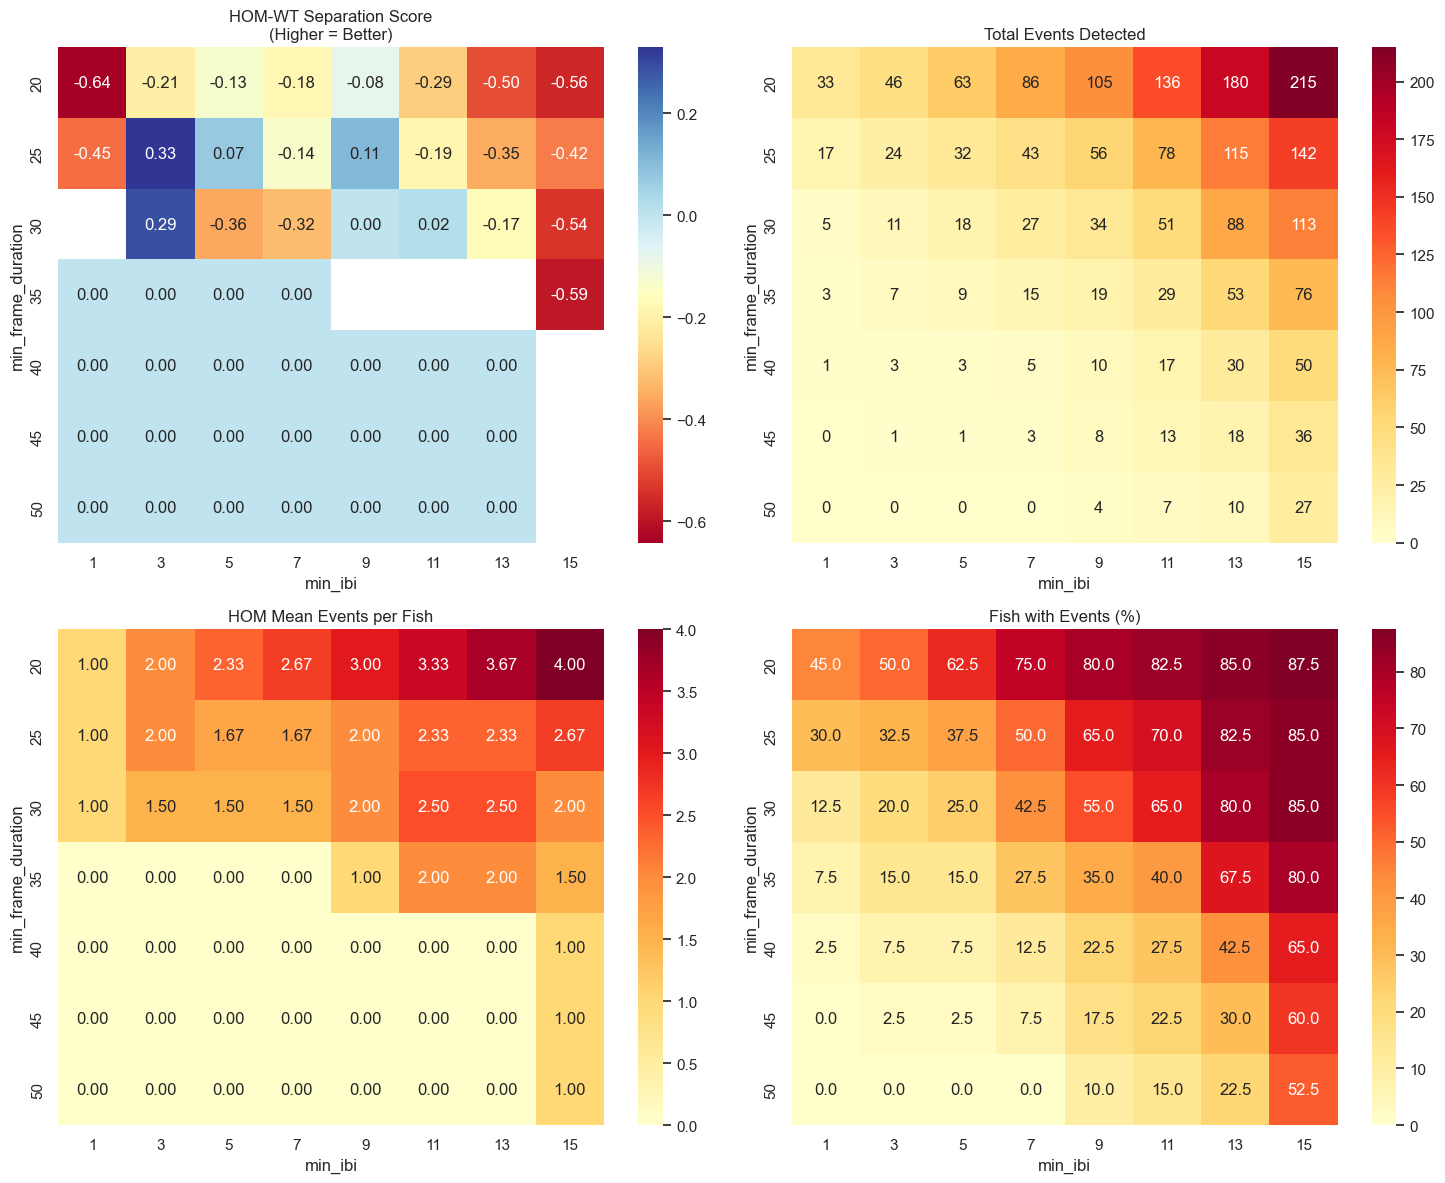

In [5]:
# Plot results
plot_parameter_sweep_standalone(sweep_results)

In [6]:
obj = para_obj_raw
save = True

# Define segments: (label, start_time, end_time)
segments = [
    # ('first5',     0,   5),
    # ('first10', 0,  10),
    ('spont',     0, 60),
    # ('drug3',    150, 190),
    # ('drug4',    200, 230),
]

event_detection_params = {
    "upper_threshold": 35,
    "lower_threshold": 2,
    "min_frame_duration": 25,
    "min_ibi": 3
}

segment_dfs = obj.process_segments(segments, event_detection_params)


Generating all_seizure_df...
{'upper_threshold': 35, 'lower_threshold': 2, 'min_frame_duration': 25, 'min_ibi': 3}
Done
Processed: 250314_16_17_ALDH7A1_paradigm_spont


genotype
Excluded     4
HET         19
HOM          5
WT          12
Name: well, dtype: int64

--- Processing Segment: 250314_16_17_ALDH7A1_paradigm, spont ---
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. HET: Custom statistical test, P_val:5.848e-01
HET vs. HOM: Custom statistical test, P_val:8.318e-01
WT vs. HOM: Custom statistical test, P_val:5.086e-01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. HET: Custom statistical test, P_val:3.458e-01
HET vs. HOM: Custom statistical test, P_val:1.000e+00
WT vs. HOM: Custom statistical test, P_val:7.150e-01

📊 Summary Stats for Segment: 250314_16_17_ALDH7A1_paradigm spont
         duration                            IBI                      

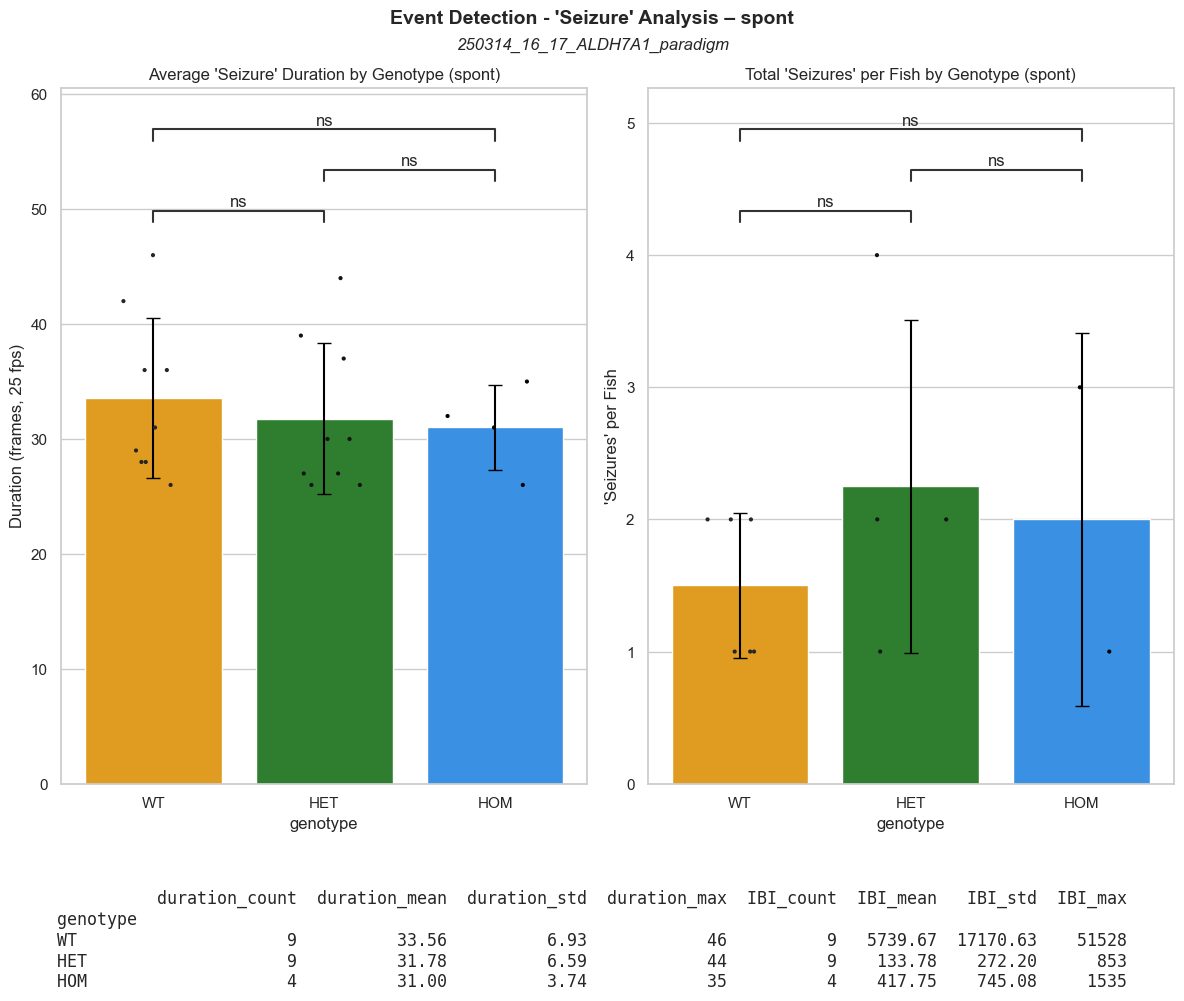

In [8]:
###### import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest, kruskal, mannwhitneyu, f_oneway, ttest_ind
from statannotations.Annotator import Annotator

n_genotype = df_raw.groupby(['genotype'], observed=False)['well'].nunique()
print(n_genotype)

for key, df in segment_dfs.items():
    if not key.startswith("all_seizure_df_"):
        continue

    exp_name = key.replace("all_seizure_df_", "").rsplit("_", 1)[0]
    segment_name = key.split("_")[-1]
    print(f"\n--- Processing Segment: {exp_name}, {segment_name} ---")

    # Define genotype order and colors
    genotype_order = ["WT", "HET", "HOM"]
    genotype_colors = {"WT": "#FFA500", "HET": "#228B22", "HOM": "#1E90FF"}

    # Ensure genotype is categorical
    df['genotype'] = pd.Categorical(df['genotype'], categories=genotype_order, ordered=True)

    # Step 1-3: Count seizures per fish and attach genotype
    seizure_counts_per_fish = df.groupby(["box", "well"]).size().reset_index(name="seizure_count")
    genotype_mapping = df.groupby(["box", "well"])["genotype"].first().reset_index()
    seizure_counts_per_fish = seizure_counts_per_fish.merge(genotype_mapping, on=["box", "well"], how="left")

    # Step 4: Summary stats
    genotype_stats = df.groupby(['genotype'], observed=False).agg(
        duration_mean=('duration', 'mean'),
        duration_std=('duration', 'std'),
        interbout_mean=('IBI', 'mean'),
        interbout_std=('IBI', 'std')
    ).reset_index().sort_values(by='genotype')

    genotype_stats_seizure_count = seizure_counts_per_fish.groupby(['genotype'], observed=False).agg(
        seizure_count_mean=('seizure_count', 'mean'),
        seizure_count_std=('seizure_count', 'std')
    ).reset_index().sort_values(by='genotype')

    # Step 5: Normality Tests
    def run_normality(data_source, measure):
        result = {}
        for genotype in genotype_order:
            vals = data_source.loc[data_source['genotype'] == genotype, measure]
            n = len(vals)
            if n > 3:
                result[genotype] = {
                    "Shapiro": shapiro(vals).pvalue,
                    "D’Agostino": normaltest(vals).pvalue if n >= 20 else None
                }
            else:
                result[genotype] = {"Shapiro": None, "D’Agostino": None}
        return result

    def is_normal(p_values):
        return all(p is not None and p >= 0.05 for p in p_values.values())

    normal_duration = run_normality(df, "duration")
    normal_count = run_normality(seizure_counts_per_fish, "seizure_count")

    duration_normal = is_normal({g: v["Shapiro"] for g, v in normal_duration.items()})
    count_normal = is_normal({g: v["Shapiro"] for g, v in normal_count.items()})

    # Step 6: Statistical Tests
    def run_tests(data, measure, normal):
        valid = [g for g in genotype_order if g in data['genotype'].unique()]
        if len(valid) < 2:
            return None, None, {}

        if normal:
            overall = f_oneway(*[data[data['genotype'] == g][measure] for g in valid]).pvalue
            pairwise = {
                pair: ttest_ind(
                    data[data['genotype'] == pair[0]][measure],
                    data[data['genotype'] == pair[1]][measure]
                ).pvalue for pair in pairwise_comparisons if pair[0] in valid and pair[1] in valid
            }
            test = "ANOVA"
        else:
            overall = kruskal(*[data[data['genotype'] == g][measure] for g in valid]).pvalue
            pairwise = {
                pair: mannwhitneyu(
                    data[data['genotype'] == pair[0]][measure],
                    data[data['genotype'] == pair[1]][measure]
                ).pvalue for pair in pairwise_comparisons if pair[0] in valid and pair[1] in valid
            }
            test = "Kruskal-Wallis"
        return test, overall, pairwise

    pairwise_comparisons = [("WT", "HET"), ("WT", "HOM"), ("HET", "HOM")]
    duration_test, duration_p, duration_pairs = run_tests(df, "duration", duration_normal)
    count_test, count_p, count_pairs = run_tests(seizure_counts_per_fish, "seizure_count", count_normal)

    # Step 7: Plotting
    # fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig, axes = plt.subplots(1, 2, figsize=(12, 8))

    def plot(ax, data, stats, y_col, y_raw, std_col, title, p_vals):
        stats = stats.set_index("genotype").reindex(genotype_order).reset_index()
        stats.fillna({y_col: 0, std_col: 0}, inplace=True)

        sns.barplot(data=stats, x="genotype", y=y_col, ax=ax, errorbar=None,
                    palette=genotype_colors, order=genotype_order, hue="genotype", legend=False)
        sns.stripplot(data=data, x="genotype", y=y_raw, ax=ax, palette='dark:black', size=3,
                      order=genotype_order, jitter=0.3, hue="genotype", legend=False)


        ax.errorbar(stats["genotype"], stats[y_col], yerr=stats[std_col],
                    fmt='none', capsize=5, ecolor='black')
        ax.set_title(title)
        # ax.set_ylabel(y_col.replace("_", " ").capitalize())

        if "duration" in y_col:
            ax.set_ylabel("Duration (frames, 25 fps)", fontsize=12)
        elif "seizure_count" in y_col:
            ax.set_ylabel("'Seizures' per Fish", fontsize=12)
        else:
            ax.set_ylabel(y_col, fontsize=12)  # fallback

        if p_vals:
            annotator = Annotator(ax, pairwise_comparisons, data=data, x="genotype", y=y_raw,
                                  order=genotype_order)
            annotator.configure(test=None, text_format="star", loc="inside")
            annotator.set_pvalues_and_annotate([p_vals.get(pair, 1) for pair in pairwise_comparisons])

    plot(axes[0], df, genotype_stats, "duration_mean", "duration", "duration_std",
         f"Average 'Seizure' Duration by Genotype ({segment_name})", duration_pairs)

    plot(axes[1], seizure_counts_per_fish, genotype_stats_seizure_count,
         "seizure_count_mean", "seizure_count", "seizure_count_std",
         f"Total 'Seizures' per Fish by Genotype ({segment_name})", count_pairs)

    # Step 8: Summary Stats Table (count, mean, std, max for duration & IBI)
    summary_stats = (
        df
        .sort_values('genotype', key=lambda x: x.map({g: i for i, g in enumerate(genotype_order)}))
        .groupby('genotype', sort=False, observed=False)[['duration', 'IBI']]
        .agg(['count', 'mean', 'std', 'max'])
    )

    # Print to console
    print(f"\n📊 Summary Stats for Segment: {exp_name} {segment_name}")
    print(summary_stats)

   # Flatten column names for compactness
    summary_stats.columns = [f"{col[0]}_{col[1]}" for col in summary_stats.columns]
    summary_stats = summary_stats.round(2)

    # Convert to compact table string
    try:
        from tabulate import tabulate
        stats_str = tabulate(
            summary_stats.reset_index(),
            headers=["Genotype"] + list(summary_stats.columns),
            tablefmt="plain",
            showindex=False
        )
    except ImportError:
        stats_str = summary_stats.to_string()


    # Place table text outside the axes (centered under both subplots)
    fig.subplots_adjust(bottom=0.25)  # make space at bottom
    fig.text(
        0.5, -0.05,  # x, y position (y is negative for below plot area)
        stats_str,
        ha='center', va='top',
        fontsize=12, family='monospace'
    )

    plt.tight_layout()
    fig = plt.gcf()  # get current figure
    fig.suptitle(f"Event Detection - 'Seizure' Analysis – {segment_name}", fontsize=14, y=1.05, fontweight='bold')

    # Subtitle (centered, just below main title)
    fig.text(0.5, 1, exp_name, ha='center', fontsize=12, style='italic')

    plt.show()


    # Save to CSV file
    # summary_stats.to_csv(f"{segment_name}_summary_stats.csv")


In [49]:
obj = ald_para_obj_raw

seg_spontaneous   = df_raw[(df_raw['elapsed_time']>= 0) & (df_raw['elapsed_time']<= 60)]
all_seizure_df_s  = obj.generate_all_seizure_df(data=seg_spontaneous)

seg_lightstim     = df_raw[(df_raw['elapsed_time']> 60) & (df_raw['elapsed_time']<= 75)]
all_seizure_df_ls = obj.generate_all_seizure_df(data=seg_lightstim)

seg_drug          = df_raw[df_raw['elapsed_time']> 75]
all_seizure_df_d  = obj.generate_all_seizure_df(data=seg_drug)


Generating all_seizure_df...
Done
Generating all_seizure_df...
Done
Generating all_seizure_df...
Done


In [61]:
summary_stats = (
    all_seizure_df_s
    .sort_values('genotype', key=lambda x: x.map({g: i for i, g in enumerate(genotype_order)}))
    .groupby('genotype', sort=False)[['duration', 'IBI']]
    .agg(['count', 'mean', 'std', 'max'])
)

summary_stats

duration                            IBI                             \
            count       mean       std max count         mean           std   
genotype                                                                      
WT              9  33.555556  6.930208  46     9  5739.666667  17170.633484   
HET             9  31.777778  6.591240  44     9   133.777778    272.196059   
HOM             4  31.000000  3.741657  35     4   417.750000    745.079582   
Excluded        2  26.500000  0.707107  27     2    11.500000      0.707107   

                 
            max  
genotype         
WT        51528  
HET         853  
HOM        1535  
Excluded     12

In [62]:
summary_stats = (
    all_seizure_df_ls
    .sort_values('genotype', key=lambda x: x.map({g: i for i, g in enumerate(genotype_order)}))
    .groupby('genotype', sort=False)[['duration', 'IBI']]
    .agg(['count', 'mean', 'std', 'max'])
)

summary_stats

duration                            IBI                         
            count       mean       std max count       mean       std max
genotype                                                                 
HET             6  30.333333  6.713171  44     6  31.166667  25.93389  65
Excluded        1  27.000000       NaN  27     1   5.000000       NaN   5

In [63]:
summary_stats = (
    all_seizure_df_d
    .sort_values('genotype', key=lambda x: x.map({g: i for i, g in enumerate(genotype_order)}))
    .groupby('genotype', sort=False)[['duration', 'IBI']]
    .agg(['count', 'mean', 'std', 'max'])
)

summary_stats

duration                             IBI                            \
            count       mean        std max count         mean          std   
genotype                                                                      
WT             74  32.256757   6.022926  50    74   241.743243   776.062225   
HET            93  32.698925   6.781985  59    93   210.322581   643.081105   
HOM            29  37.758621  13.075755  87    29    82.620690   140.462861   
Excluded       30  37.566667  12.144769  71    30  1592.200000  8329.713223   

                 
            max  
genotype         
WT         6017  
HET        3876  
HOM         586  
Excluded  45689

Seizure Duration Data Normal? False
Seizure Count Data Normal? True
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. HET: Custom statistical test, P_val:7.935e-01
HET vs. HOM: Custom statistical test, P_val:6.066e-02
WT vs. HOM: Custom statistical test, P_val:6.703e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. HET: Custom statistical test, P_val:6.017e-01
HET vs. HOM: Custom statistical test, P_val:8.636e-01
WT vs. HOM: Custom statistical test, P_val:8.538e-01


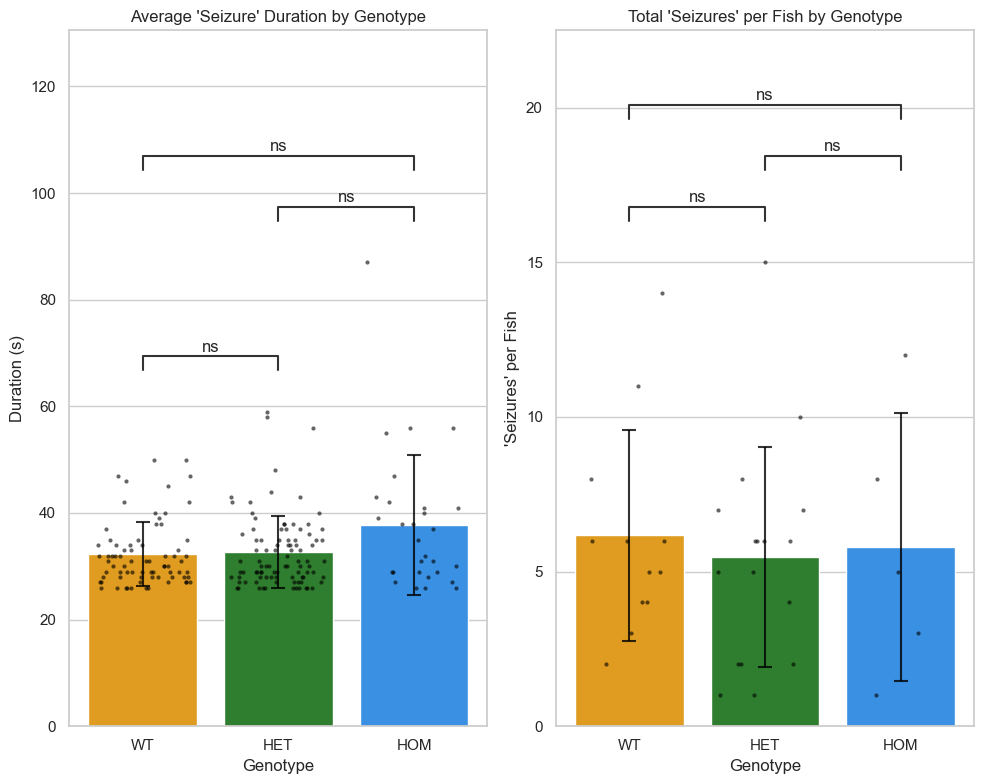

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest, kruskal, mannwhitneyu, f_oneway, ttest_ind
from statannotations.Annotator import Annotator

# all_seizure_df = all_seizure_df_s
# all_seizure_df = all_seizure_df_ls
all_seizure_df = all_seizure_df_d

# Define genotype order and colors
genotype_order = ["WT", "HET", "HOM"]
genotype_colors = {"WT": "#FFA500", "HET": "#228B22", "HOM": "#1E90FF"}

# Ensure genotype is categorical
all_seizure_df['genotype'] = pd.Categorical(all_seizure_df['genotype'], categories=genotype_order, ordered=True)

# Step 1: Count seizures per fish (group by `box`, `well`)
seizure_counts_per_fish = all_seizure_df.groupby(["box", "well"]).size().reset_index(name="seizure_count")

# Step 2: Extract genotype for each fish (keep only first occurrence)
genotype_mapping = all_seizure_df.groupby(["box", "well"])["genotype"].first().reset_index()

# Step 3: Merge genotype back
seizure_counts_per_fish = seizure_counts_per_fish.merge(genotype_mapping, on=["box", "well"], how="left")

# Step 4: Compute summary statistics per genotype
genotype_stats = all_seizure_df.groupby(['genotype'], observed=False).agg(
    duration_mean=('duration', 'mean'),
    duration_std=('duration', 'std'),
    interbout_mean=('IBI', 'mean'),
    interbout_std=('IBI', 'std')
).reset_index()

# Fix: Group seizure_counts_per_fish by genotype, not well
genotype_stats_seizure_count = seizure_counts_per_fish.groupby(['genotype'], observed=False).agg(
    seizure_count_mean=('seizure_count', 'mean'),
    seizure_count_std=('seizure_count', 'std')
).reset_index()

# **Sort for proper ordering**
genotype_stats = genotype_stats.sort_values(by=['genotype'])
genotype_stats_seizure_count = genotype_stats_seizure_count.sort_values(by=['genotype'])


# **Step 5: Normality Tests**
normality_results = {}

for measure, data_source in [("duration", all_seizure_df), ("seizure_count", seizure_counts_per_fish)]:
    normality_results[measure] = {}
    
    for genotype in genotype_order:
        data = data_source.loc[data_source['genotype'] == genotype, measure]
        n = len(data)
        
        if n > 3:  # Ensure at least 3 values before running normality test
            shapiro_p = shapiro(data).pvalue
            dagostino_p = normaltest(data).pvalue if n >= 20 else None  # Skip `normaltest()` if n < 20
            
            normality_results[measure][genotype] = {
                "Shapiro-Wilk p": shapiro_p,
                "D’Agostino-Pearson p": dagostino_p
            }
        else:
            normality_results[measure][genotype] = {
                "Shapiro-Wilk p": None,
                "D’Agostino-Pearson p": None
            }


# Function to determine normality
# def is_normal(p_values):
#     return all(p >= 0.05 for p in p_values.values())

# def is_normal(p_values):
#     for genotype, p in p_values.items():
#         if p is None:
#             print(f"Skipping {genotype} due to missing p-value.")
#     return all(p is not None and p >= 0.05 for p in p_values.values() if p is not None)

def is_normal(p_values):
    skipped_groups = [g for g, p in p_values.items() if p is None]

    if skipped_groups:
        print(f"Skipping normality test for: {', '.join(skipped_groups)} (too few data points)")

    return all(p is not None and p >= 0.05 for p in p_values.values() if p is not None)

# Check normality
is_duration_normal = is_normal({g: normality_results["duration"][g]["Shapiro-Wilk p"] for g in genotype_order})
is_seizure_count_normal = is_normal({g: normality_results["seizure_count"][g]["Shapiro-Wilk p"] for g in genotype_order})

print(f"Seizure Duration Data Normal? {is_duration_normal}")
print(f"Seizure Count Data Normal? {is_seizure_count_normal}")

# **Step 6: Statistical Tests**
def run_statistical_tests(data, measure, is_normal):
    valid_groups = [g for g in genotype_order if g in data['genotype'].unique()]

    if len(valid_groups) < 2:
        print(f"⚠️ Not enough valid genotype groups for {measure} comparison. Skipping statistical tests.")
        return None, None, {}

    if is_normal:
        overall_p = f_oneway(*[data.loc[data['genotype'] == g, measure] for g in valid_groups]).pvalue
        test_name = "ANOVA"
        pairwise_tests = {
            pair: ttest_ind(
                data.loc[data['genotype'] == pair[0], measure],
                data.loc[data['genotype'] == pair[1], measure]
            ).pvalue
            for pair in pairwise_comparisons if pair[0] in valid_groups and pair[1] in valid_groups
        }
    else:
        overall_p = kruskal(*[data.loc[data['genotype'] == g, measure] for g in valid_groups]).pvalue
        test_name = "Kruskal-Wallis"
        pairwise_tests = {
            pair: mannwhitneyu(
                data.loc[data['genotype'] == pair[0], measure],
                data.loc[data['genotype'] == pair[1], measure]
            ).pvalue
            for pair in pairwise_comparisons if pair[0] in valid_groups and pair[1] in valid_groups
        }

    return test_name, overall_p, pairwise_tests
    
pairwise_comparisons = [("WT", "HET"), ("WT", "HOM"), ("HET", "HOM")]

# # Run tests for both measures
# duration_test_name, duration_p, duration_pairwise_tests = run_statistical_tests(all_seizure_df, "duration", is_duration_normal)
# seizure_count_test_name, seizure_count_p, seizure_count_pairwise_tests = run_statistical_tests(seizure_counts_per_fish, "seizure_count", is_seizure_count_normal)

# Run statistical tests
# duration_test_name, duration_p, duration_pairwise_tests = run_statistical_tests(
#     all_seizure_df, "duration", is_duration_normal
# )
# seizure_count_test_name, seizure_count_p, seizure_count_pairwise_tests = run_statistical_tests(
#     seizure_counts_per_fish, "seizure_count", is_seizure_count_normal
# )

# # Prevent annotation if no valid tests
# if not duration_pairwise_tests:
#     print("⚠️ Skipping annotation for duration: Not enough valid comparisons.")

# if not seizure_count_pairwise_tests:
#     print("⚠️ Skipping annotation for seizure count: Not enough valid comparisons.")

# # Print results
# print(f"\nSeizure Duration Test Used: {duration_test_name} | p = {duration_p:.4f}")
# for pair, p_val in duration_pairwise_tests.items():
#     print(f"{pair[0]} vs {pair[1]}: p = {p_val:.4f}")

# print(f"\nSeizure Count Test Used: {seizure_count_test_name} | p = {seizure_count_p:.4f}")
# for pair, p_val in seizure_count_pairwise_tests.items():
#     print(f"{pair[0]} vs {pair[1]}: p = {p_val:.4f}")

# **Plotting**
# fig, axes = plt.subplots(1, 2, figsize=(10, 8))

# def plot_with_points_and_error(ax, data, stats, y_col, y, std_col, y_label, title, p_values):
#     sns.barplot(
#         data=stats,
#         x="genotype",
#         y=y_col,
#         errorbar=None,
#         order=genotype_order, 
#         ax=ax,
#         hue="genotype",  # Explicitly set hue to match x-variable
#         palette=genotype_colors,  
#         legend=False  
#     )
#     sns.stripplot(
#         data=data,
#         x="genotype",
#         y=y,
#         dodge=False,
#         jitter=0.35,
#         order=genotype_order, ax=ax, color='black', alpha=0.6, size=3
#     )
#     ax.errorbar(
#         stats["genotype"], stats[y_col], yerr=stats[std_col],
#         fmt='none', ecolor='black', capsize=5, capthick=1.5, alpha=0.8
#     )

#     ax.set_title(title, fontsize=12)
#     ax.set_xlabel('Genotype', fontsize=12)
#     ax.set_ylabel(y_label, fontsize=12)
#     ax.set_ylim(0, data[y].max() * 1.5)  

#     # **Statistical annotations**
#     pairs = [("WT", "HET"), ("WT", "HOM"), ("HET", "HOM")]
#     annotator = Annotator(ax, pairs, data=data, x="genotype", y=y, order=genotype_order)
#     annotator.configure(test=None, text_format="star", loc="inside")
#     annotator.set_pvalues_and_annotate([p_values.get(pair, 1) for pair in pairs])

def plot_with_points_and_error(ax, data, stats, y_col, y, std_col, y_label, title, p_values):
    # Ensure all genotypes are included by reindexing with full genotype order
    stats = stats.set_index("genotype").reindex(genotype_order).reset_index()
    
    # Fill NaN values with 0 (so missing genotypes still appear)
    stats.fillna({y_col: 0, std_col: 0}, inplace=True)

    sns.barplot(
        data=stats,
        x="genotype",
        y=y_col,
        errorbar=None,
        order=genotype_order, 
        ax=ax,
        hue="genotype",
        palette=genotype_colors,  
        legend=False  
    )
    sns.stripplot(
        data=data,
        x="genotype",
        y=y,
        dodge=False,
        jitter=0.35,
        order=genotype_order, ax=ax, color='black', alpha=0.6, size=3
    )
    ax.errorbar(
        stats["genotype"], stats[y_col], yerr=stats[std_col],
        fmt='none', ecolor='black', capsize=5, capthick=1.5, alpha=0.8
    )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Genotype', fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_ylim(0, data[y].max() * 1.5 if not data[y].isna().all() else 1)  # Prevents scaling errors if all values are NaN

    # Only annotate if valid p-values exist
    if p_values:
        pairs = [("WT", "HET"), ("WT", "HOM"), ("HET", "HOM")]
        annotator = Annotator(ax, pairs, data=data, x="genotype", y=y, order=genotype_order)
        annotator.configure(test=None, text_format="star", loc="inside")
        annotator.set_pvalues_and_annotate([p_values.get(pair, 1) for pair in pairs])
    else:
        print(f"⚠️ Skipping annotation for {title}: Not enough valid data.")

# # **Plot 1: Seizure Duration**
# plot_with_points_and_error(
#     axes[0], all_seizure_df, genotype_stats, 
#     "duration_mean", "duration", "duration_std", 
#     "Duration (s)", "Average 'Seizure' Duration by Genotype", 
#     duration_pairwise_tests
# )

# # **Plot 2: Seizure Count per Fish**
# plot_with_points_and_error(
#     axes[1], seizure_counts_per_fish, genotype_stats_seizure_count, 
#     "seizure_count_mean", "seizure_count", "seizure_count_std", 
#     "'Seizures' per Fish", "Total 'Seizures' per Fish by Genotype", 
#     seizure_count_pairwise_tests
# )


# Run statistical tests
duration_test_name, duration_p, duration_pairwise_tests = run_statistical_tests(
    all_seizure_df, "duration", is_duration_normal
)
seizure_count_test_name, seizure_count_p, seizure_count_pairwise_tests = run_statistical_tests(
    seizure_counts_per_fish, "seizure_count", is_seizure_count_normal
)

# Prevent annotation if no valid tests
if not duration_pairwise_tests:
    print("⚠️ Skipping annotation for duration: Not enough valid comparisons.")

if not seizure_count_pairwise_tests:
    print("⚠️ Skipping annotation for seizure count: Not enough valid comparisons.")

# Always plot, even if statistical tests are missing
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

# **Plot 1: Seizure Duration**
plot_with_points_and_error(
    axes[0], all_seizure_df, genotype_stats, 
    "duration_mean", "duration", "duration_std", 
    "Duration (s)", "Average 'Seizure' Duration by Genotype", 
    duration_pairwise_tests
)

# **Plot 2: Seizure Count per Fish**
plot_with_points_and_error(
    axes[1], seizure_counts_per_fish, genotype_stats_seizure_count, 
    "seizure_count_mean", "seizure_count", "seizure_count_std", 
    "'Seizures' per Fish", "Total 'Seizures' per Fish by Genotype", 
    seizure_count_pairwise_tests
)

plt.tight_layout()

# Save figure with transparent background
# plt.savefig("250214_14_15_ALDH7A1_20LYS_7dpf.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()

In [20]:
# Check data types


print(all_seizure_df.dtypes)
print(seizure_counts_per_fish.dtypes)

# Check for non-numeric values in numeric columns
print("Non-numeric values in duration:")
print(all_seizure_df[~all_seizure_df['duration'].apply(lambda x: isinstance(x, (int, float)))]['duration'])

print("Non-numeric values in IBI:")
print(all_seizure_df[~all_seizure_df['IBI'].apply(lambda x: isinstance(x, (int, float)))]['IBI'])

print("Non-numeric values in seizure_count:")
print(seizure_counts_per_fish[~seizure_counts_per_fish['seizure_count'].apply(lambda x: isinstance(x, (int, float)))]['seizure_count'])

start         object
end           object
duration       int64
IBI            int64
box            int64
well          object
genotype    category
dtype: object
box                 int64
well               object
seizure_count       int64
genotype         category
dtype: object
Non-numeric values in duration:
Series([], Name: duration, dtype: int64)
Non-numeric values in IBI:
Series([], Name: IBI, dtype: int64)
Non-numeric values in seizure_count:
Series([], Name: seizure_count, dtype: int64)


In [36]:
ald_para_obj_raw.all_seizure_df['genotype'].value_counts()


genotype
HET         93
WT          74
Excluded    30
HOM         29
Name: count, dtype: int64

In [33]:
all_seizure_df_ls['genotype'].value_counts()

genotype
HET    6
WT     0
HOM    0
Name: count, dtype: int64

In [34]:
all_seizure_df_s['genotype'].value_counts()

genotype
WT     9
HET    9
HOM    4
Name: count, dtype: int64

In [43]:
# seg_spontaneous   = df_raw[(df_raw['elapsed_time']>= 0) & (df_raw['elapsed_time']<= 60)]
# all_seizure_df_s  = ald_para_obj_raw.generate_all_seizure_df(data=seg_spontaneous)

seg_lightstim     = df_raw[(df_raw['elapsed_time']> 60) & (df_raw['elapsed_time']<= 75)]
all_seizure_df_ls = ald_para_obj_raw.generate_all_seizure_df(data=seg_lightstim)

# seg_drug          = df_raw[df_raw['elapsed_time']> 75]
# all_seizure_df_d  = ald_para_obj_raw.generate_all_seizure_df(data=seg_drug)
# print(len(seg_spontaneous), len(seg_lightstim), len(seg_drug))

Generating all_seizure_df...


In [42]:
# Define thresholds
# upper_threshold    = 35  # Activity level for potential seizure
# lower_threshold    = 2  # Defines "zero" or near-zero baseline
# min_frame_duration = 25  # Minimum frames required to qualify as a seizure event
# min_ibi            = 3  # Minimum interbout interval to confirm a separate event

# Ensure data is sorted by time (but maintain original index)
fish = fish.sort_values(by="fullts", ignore_index=True)

# Create a boolean column indicating if data1 is above the threshold
fish["above_threshold"] = fish["data1"] >= upper_threshold
fish["below_threshold"] = fish["data1"] <= lower_threshold

# Initialize variables
seizure_events = []  # Stores (start_index, end_index, duration, IBI)
temp_events    = []
in_seizure     = False  # Flag to track if we're currently in a seizure
start_index    = None  # To store the start of the bout
end_index      = None  # To store the end of the bout

next_start_index = None  # Tracks the next event's start

potential_event_end = None
frame_count = 0

# Convert DataFrame index to a list to ensure correct referencing
frame_indices = fish.index.tolist()

# Detect seizure events

for i, row in fish.iterrows():
    # print(i)
    if row["above_threshold"]:
        # print(f"^ this one is above threshold (upper_threshold})")
        if not in_seizure:
            for j in range(i, -1, -1): # Look backward for bout start
                if fish.loc[j, 'below_threshold']:
                    start_index = j
                    # print("START: index=",start_index, "elapsed_time=",fishC2.loc[start_index, 'elapsed_time'])
                    break

            # Fix: If no below_threshold was found, default to i
            if start_index is None:
                start_index = i  # Assign i to prevent NoneType errors

            in_seizure  = True
            frame_count = 0

    else: # if row is not above upper threshold
        if in_seizure: # but still in seizure and data1 is below the lower threshold


            if row["below_threshold"]:
                # print(f"This is below the lower bound ({lower_threshold})")
                if potential_event_end == None:
                    potential_event_end = i
                else:
                    frame_count += 1
                # print(f"This is a potential end; {frame_count}")
            else:
                # print('Above lower threshold count:',frame_count)
                if frame_count <= min_ibi: # This means that the event is still ongoing
                    # duration  = potential_event_end - start_index
                    potential_event_end = frame_count
                    temp_event = (start_index, potential_event_end, frame_count, i)
                    temp_events.append(temp_event)
                    # print(f"temp_event: {temp_event}")
                    frame_count = 0

                elif len(temp_events)>0:
                    # print(f"temp_events: {temp_events}")
                    last_temp_event = temp_events.pop()

                    end_index = last_temp_event[3]+1
                    duration  = end_index - start_index
                    ibi       = (i-1) - end_index
                    # print(i)
                    event     = (start_index, end_index, duration, ibi)
                    if duration > min_frame_duration:
                        seizure_events.append(event)
                    temp_events     = []


                else:


                    end_index = potential_event_end
                    ibi       = frame_count
                    duration  = end_index - start_index
                    # print(temp_events)

                    if duration > min_frame_duration:
                        seizure_events.append((start_index, end_index, duration, ibi))
                        # print(f'START: {start_index}, END: {end_index}, ibi: {ibi}')
                        start_index = end_index + ibi

                    in_seizure = False
                    end_index = None
                    potential_event_end = None  # Reset temporary marker
                    frame_count = 0
                    # temp_events = []

#TODO
# if in_seizure:
#     duration = len(fishC2) - start_index
#     if duration > min_frame_duration:
#         ibi = start_index - last_end_index if last_end_index is not None else None
#         seizure_events.append((start_index, len(fishC2) - 1, duration, ibi))


    # if i == 300: break

# Convert seizure events to DataFrame
seizure_df = pd.DataFrame(seizure_events, columns=["start", "end", "duration", "IBI"])

# Convert 'duration' and 'IBI' to numeric immediately
seizure_df['duration'] = pd.to_numeric(seizure_df['duration'], errors='coerce')
seizure_df['IBI'] = pd.to_numeric(seizure_df['IBI'], errors='coerce')

if plot:
    self.plot_events(fish, seizure_df, frame_indices, upper_threshold, lower_threshold)

,fullts,elapsed_time,box,well,genotype,data1
0,2025-03-14 18:29:32.047473000,0.000000,16,A1,HET,0.0
1,2025-03-14 18:29:32.047473000,0.000000,16,A2,HET,0.0
2,2025-03-14 18:29:32.047473000,0.000000,16,A3,Excluded,0.0
3,2025-03-14 18:29:32.047473000,0.000000,16,A4,HOM,0.0
4,2025-03-14 18:29:32.047473000,0.000000,16,A5,HET,0.0
...,...,...,...,...,...,...
3596835,2025-03-14 19:29:32.047341000,59.999998,16,C12,HET,0.0
3596836,2025-03-14 19:29:32.047341000,59.999998,16,D1,HET,0.0
3596837,2025-03-14 19:29:32.047341000,59.999998,16,D2,HET,0.0
3596838,2025-03-14 19:29:32.047341000,59.999998,16,D3,HET,0.0
